<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_4_nested_cv_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How our model-evaluation strategy has changed

## The basic Train-Test split.
When we use a Train-Test split for model evaluation, we randomly select a subset of the data (e.g., 20%) to set aside, and train our model on the remaining data. Note: When doing this alongside data transformations like standardization, we must fit the standardizer only on the training data to prevent leakage, and then apply it to the test data.

---

## Train/Test with Cross-Validation
When using cross-validation with a test set, we first do the Train-Test split. Then, we take the training data and split it again into multiple cross-validation folds. We train on most of the folds and use the remaining fold for validation, repeating this until every fold has been used as a validation set. We average the performance scores across these folds to find the best hyperparameters. Then, we train a single, brand-new model on the entire training set using those best hyperparameters, and test it on the original set-aside test set.

---

## Nested Cross-Validation
With nested cross-validation, there is no original locked-away test set. Instead, all the data is used for testing via two loops. The Inner Loop handles hyperparameter tuning: it runs cross-validation to find the best hyperparameters for a specific slice of data. This is 'nested' inside an Outer Loop, which holds out a different test fold each time to evaluate the model produced by the inner loop. To gauge overall performance, we simply average the test scores from the outer loop. This tells us how well our model-building process works on unseen data.

# The Evolution of Model Evaluation: Why Nested Cross-Validation?

If you're feeling a little dizzy from the way we keep changing how we split our data, you are not alone!

First, we told you to use a **Train/Test split**.
Then, we said, "Wait, use **Cross-Validation on the training data, plus a Test split**."
Now, we are talking about ditching the single test split entirely in favor of **Nested Cross-Validation**.

Why do we keep moving the goalposts? The short answer: **Hyperparameter tuning changes everything.**

Let's walk through this progression using a concrete analogy: **Studying for a Final Exam with a Massive Problem Bank.** In this analogy:
* **Training Data** = A bank of math problems you use for practice.
* **Validation Data** = Mini-quizzes you take to see if your study strategy is working.
* **Test Data** = The actual Final Exam.
* **Hyperparameter Tuning** = Changing your study strategy (e.g., trying flashcards vs. solving by graphing vs. algebraic substitution) to see what gets you the best score on the mini-quizzes.

## Stage 1: The Simple Train / Test Split
When we first learned Machine Learning, we split our data once.

**The Analogy:** You have a bank of 1,000 math problems. You practice on 800 of them (Train), and then you take a final exam made of the remaining 200 problems (Test).

**The Problem:** Luck. What if the 200 exam problems happen to feature the exact type of fractions you struggle with? Or what if they are unusually easy?

Because we only test *once*, our evaluation of the model is highly dependent on how the data was randomly split. We have high **variance** in our evaluation.

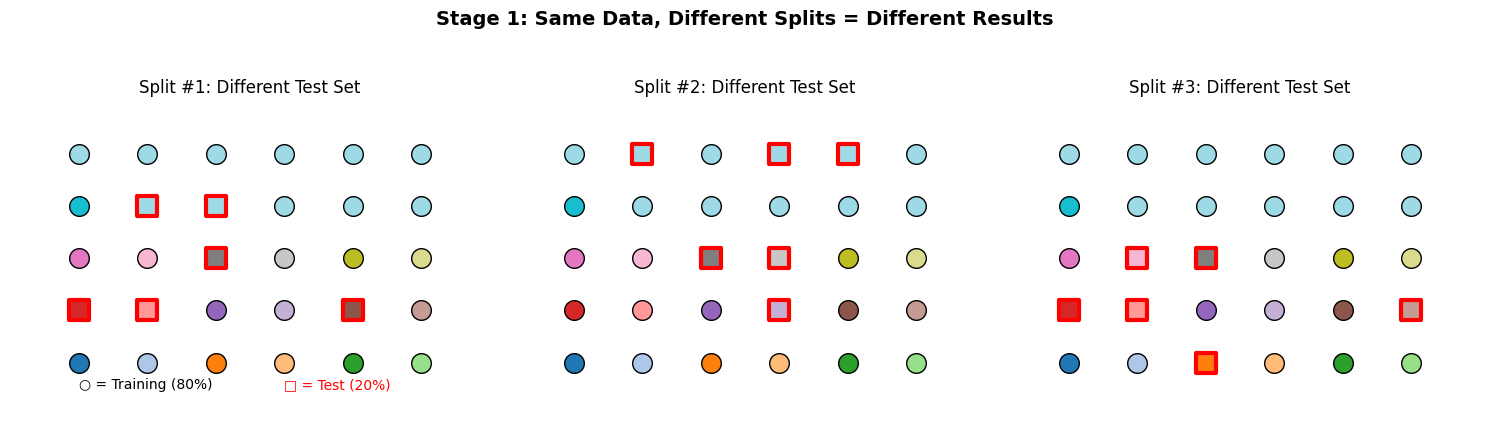

In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_points = 30
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    perm = np.random.permutation(n_points)
    train_idx = perm[:int(0.8 * n_points)]
    test_idx = perm[int(0.8 * n_points):]

    for idx in train_idx:
        ax.scatter(idx % 6, idx // 6, color=plt.cm.tab20(idx / 20), s=200, marker='o', edgecolors='black', linewidth=1)
    for idx in test_idx:
        ax.scatter(idx % 6, idx // 6, color=plt.cm.tab20(idx / 20), s=200, marker='s', edgecolors='red', linewidth=3)

    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 5)
    ax.set_title(f'Split #{i+1}: Different Test Set', fontsize=12)
    ax.axis('off')

    if i == 0:
        ax.text(0, -0.5, '○ = Training (80%)', fontsize=10)
        ax.text(3, -0.5, '□ = Test (20%)', fontsize=10, color='red')

plt.suptitle('Stage 1: Same Data, Different Splits = Different Results', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Stage 2: Cross-Validation + Held-Out Test Set
To fix the "lucky/unlucky split" problem, we introduced K-Fold Cross Validation. But because we still need a final, unbiased evaluation, we lock away a Test set at the very beginning.

**The Analogy:** You lock 200 problems away in a vault (Test set). With the 800 problems you have left, you divide them into 5 blocks of 160 problems. You practice on 4 blocks and take a mini-quiz on the 5th. You rotate this 5 times so every one of the 800 problems gets used for practice and for a quiz.

Crucially, **this is where we do Hyperparameter Tuning.** We try different study strategies (Graphing, Algebra, etc.). We pick the strategy that gives us the highest *average* score across all the mini-quizzes. Finally, we take the real Final Exam in the vault.

**The Problem:** This is great for large datasets, but on smaller ones:
1. **Wasted Data:** We locked 20% of our precious data in a drawer. The model never got to train on it before the final evaluation!
2. **Overfitting to the Validation Set:** If you tune 1,000 different combinations of hyperparameters, you are eventually going to find a combination that performs amazingly on the mini-quizzes purely by chance.
3. **The Unlucky Test Set Returns:** Because we tuned so heavily, the locked-away Test set is our *only* true measure. But what if *that* single Test set is an unlucky split? We are right back to the Stage 1 problem!

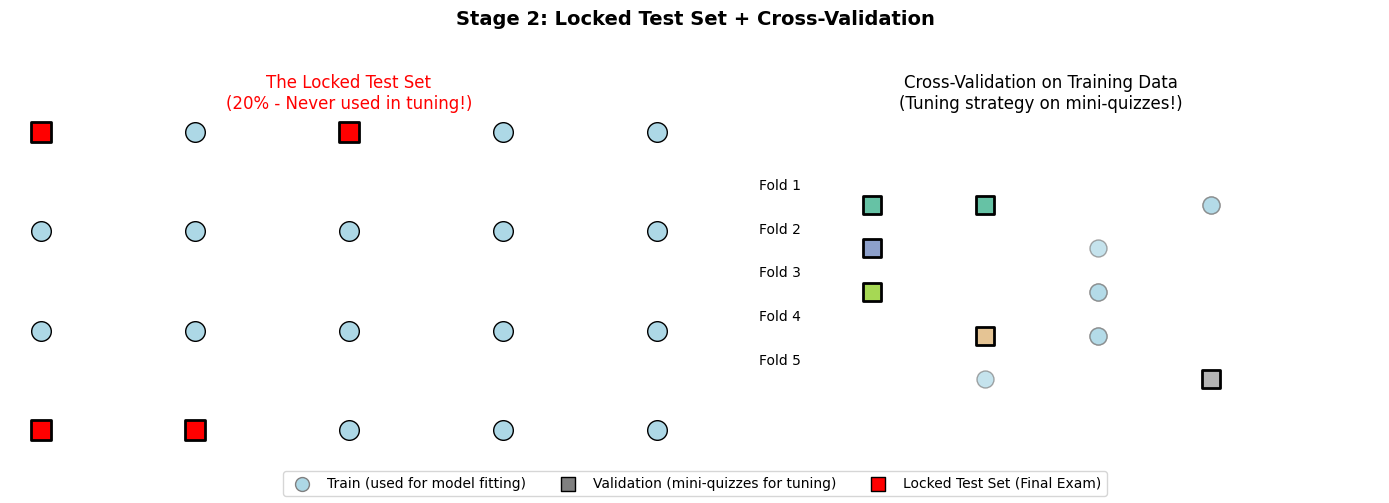

In [6]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n_points = 20
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

test_locked = np.random.choice(n_points, int(0.2 * n_points), replace=False)
train_set = [i for i in range(n_points) if i not in test_locked]

for idx in train_set:
    ax1.scatter(idx % 5, idx // 5, color='lightblue', s=200, marker='o', edgecolors='black')
for idx in test_locked:
    ax1.scatter(idx % 5, idx // 5, color='red', s=200, marker='s', edgecolors='black', linewidth=2)

ax1.set_title('The Locked Test Set\n(20% - Never used in tuning!)', fontsize=12, color='red')
ax1.axis('off')

n_folds = 5
train_array = np.array(train_set)
np.random.shuffle(train_array)
colors = plt.cm.Set2(np.linspace(0, 1, n_folds))

y_positions = [3, 2.4, 1.8, 1.2, 0.6]
for fold_idx, (y_pos, color) in enumerate(zip(y_positions, colors)):
    fold_data = train_array[fold_idx::n_folds]
    val_size = max(1, len(fold_data) // 2)
    val_data = fold_data[:val_size]
    train_data = fold_data[val_size:]

    for idx in train_data:
        ax2.scatter(idx % 4 + 0.5, y_pos - 0.2, color='lightblue', s=150, marker='o', edgecolors='gray', alpha=0.7)
    for idx in val_data:
        ax2.scatter(idx % 4 + 0.5, y_pos - 0.2, color=color, s=150, marker='s', edgecolors='black', linewidth=2)

    ax2.text(-0.5, y_pos, f'Fold {fold_idx+1}', fontsize=10)

ax2.set_title('Cross-Validation on Training Data\n(Tuning strategy on mini-quizzes!)', fontsize=12)
ax2.set_xlim(-1, 5)
ax2.set_ylim(-0.5, 4)
ax2.axis('off')

plt.figlegend([plt.scatter([], [], color='lightblue', s=100, marker='o', edgecolors='gray'),
               plt.scatter([], [], color='gray', s=100, marker='s', edgecolors='black'),
               plt.scatter([], [], color='red', s=100, marker='s', edgecolors='black')],
              ['Train (used for model fitting)', 'Validation (mini-quizzes for tuning)', 'Locked Test Set (Final Exam)'],
              loc='lower center', ncol=3, frameon=True)

plt.suptitle('Stage 2: Locked Test Set + Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Stage 3: Nested Cross-Validation (The Ultimate Solution)
How do we evaluate a heavily-tuned model without locking away 20% of our data forever? **Nested Cross Validation.**

Instead of having a single Test set, we use Cross-Validation to create our Test sets (the **Outer Loop**), and *inside* of that, we use Cross-Validation again to tune our hyperparameters (the **Inner Loop**).

**The Analogy:**
You divide all 1,000 problems into 5 blocks of 200.
1. For the first "Final Exam", you use Block 1. You use the other 800 problems to find your best study strategy (via mini-quizzes), and then take the Final Exam on Block 1.
2. Then, you wipe your memory.
3. For the second "Final Exam", you use Block 2. You use the *other* 800 problems (the original Block 1 is now available for practice!) to find your best strategy, and then take the Final Exam on Block 2.

### Why is this so powerful?
Notice what happens in Nested CV: **Every single data point gets to be on a Final Exam exactly once.**

We are no longer evaluating a *single model*. We are evaluating our **Model Building Process**. We are proving: "If I take a subset of data, tune hyperparameters, and test it on unseen data, how well does that overall process work on average?"

Once we prove the *process* works via Nested CV, we can confidently train one final model on **100% of our data**, tuning the hyperparameters one last time, and deploy it to the real world.

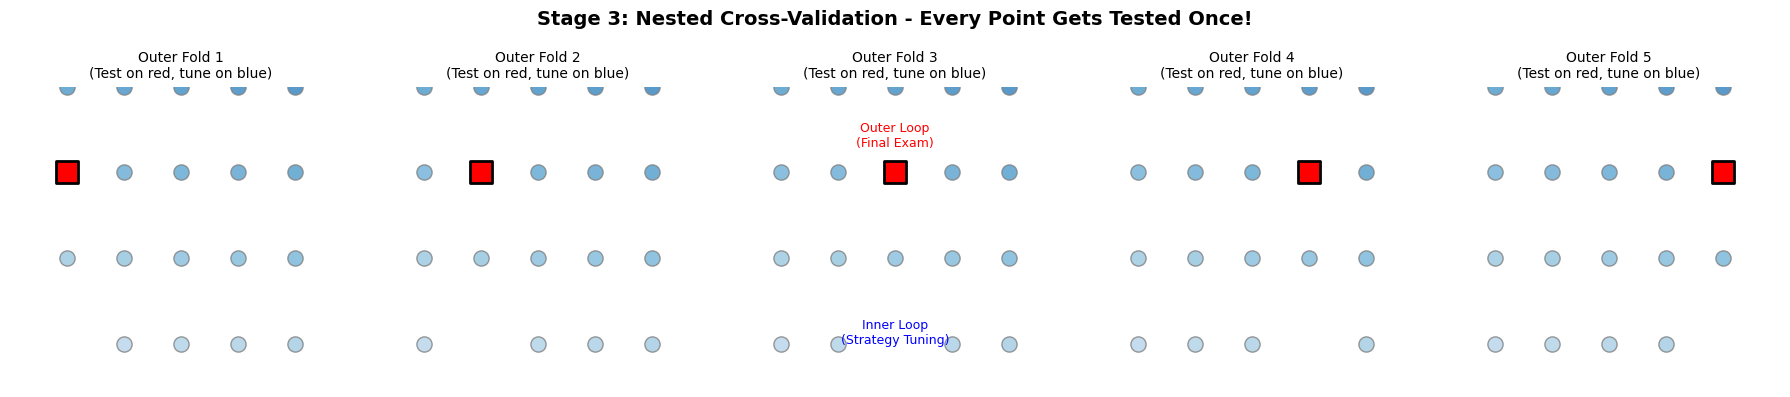

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

np.random.seed(42)
n_points = 25
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for fold_idx, ax in enumerate(axes):
    outer_test = [fold_idx]
    inner_train = [i for i in range(n_points) if i != fold_idx]

    ax.scatter(fold_idx % 5, 2, color='red', s=250, marker='s', edgecolors='black', linewidth=2, zorder=5)

    inner_colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(inner_train)))
    for i, idx in enumerate(inner_train):
        ax.scatter(idx % 5, idx // 5, color=[inner_colors[i]], s=120, marker='o', edgecolors='gray', alpha=0.8)

    ax.set_xlim(-1, 5)
    ax.set_ylim(-0.5, 3)
    ax.set_title(f'Outer Fold {fold_idx+1}\n(Test on red, tune on blue)', fontsize=10)
    ax.axis('off')

    if fold_idx == 2:
        ax.annotate('Inner Loop\n(Strategy Tuning)', xy=(2, 0), fontsize=9, ha='center', color='blue')
        ax.annotate('Outer Loop\n(Final Exam)', xy=(2, 2.3), fontsize=9, ha='center', color='red')

plt.suptitle('Stage 3: Nested Cross-Validation - Every Point Gets Tested Once!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Implementing Nested CV in Scikit-Learn
Let's look at how incredibly simple this is to code in `scikit-learn`.

In [8]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

# Load a relatively small dataset
X, y = load_breast_cancer(return_X_y=True)

# Define our model and the hyperparameters we want to tune
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

# ---------------------------------------------------------
# STAGE 2: Standard CV + Test Split (What we used to do)
# ---------------------------------------------------------
# We define an Inner CV for hyperparameter tuning.
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
clf = GridSearchCV(estimator=model, param_grid=param_grid, cv=inner_cv)

# ---------------------------------------------------------
# STAGE 3: NESTED CV (The Magic Trick)
# ---------------------------------------------------------
# We define an Outer CV for evaluating the entire tuning process.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# THE MAGIC: We pass the GridSearchCV object (which contains the inner CV)
# into cross_val_score (which acts as the outer CV).
nested_scores = cross_val_score(clf, X=X, y=y, cv=outer_cv)

print("Nested CV Scores for each Outer Fold:")
for i, score in enumerate(nested_scores):
    print(f"Outer Fold {i+1}: {score:.4f}")

print(f"\nUnbiased Estimate of Model Performance: {nested_scores.mean():.4f} (+/- {nested_scores.std():.4f})")

Nested CV Scores for each Outer Fold:
Outer Fold 1: 0.9561
Outer Fold 2: 0.9649
Outer Fold 3: 0.9386
Outer Fold 4: 0.9649
Outer Fold 5: 0.9646

Unbiased Estimate of Model Performance: 0.9578 (+/- 0.0102)


### Summary: When to use what?

1. **Train/Test Split:** Use for very quick and dirty baselines, or if you have an absolutely massive dataset (Millions of rows) where "lucky splits" are statistically impossible.
2. **CV + Held-out Test Set:** Use when you have a medium-to-large dataset, and you are only doing light hyperparameter tuning.
3. **Nested CV:** Use when you have a small dataset (e.g., medical data, thousands of rows or less) AND you are testing many different models or doing heavy hyperparameter tuning. It prevents data leakage and ensures your final performance metric is mathematically sound.